# Graph-DTW Visualization

Align one **A-edge** to the **whole local directed graph** of nearby **B-edges**, and visualize
the subgraph, the chosen route, and **every individual point match**.

> Note: edge **a** is drawn **shifted slightly** (parameter `a_shift`) so the match links are
> visible -- the matching itself uses A's true coordinates, so the reported drift is unchanged.

Legend
- **Blue** line = the A-edge (shifted for clarity); small blue dots = its densified points.
- B-edges: **green (thick)** = chosen into the route, gray (thin) = present but unused.
- B-graph vertices: **hollow dark** = original B node, small gray = interpolation point,
  **purple ring** = junction (endpoint shared by >1 B-edge -> where the route may cross).
- Match links (one per A point): **crimson `o`** = matched to a B node (point-to-point),
  **orange `x`** = matched to an interpolation point (point-to-projection).

See [`docs/graph_dtw_matching.md`](../docs/graph_dtw_matching.md) for the algorithm.


In [1]:
import sys, os
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString

sys.path.append(os.path.abspath(".."))
from network_matching import match_edge_to_bgraph

print("Imported graph-DTW.")


Imported graph-DTW.


In [2]:
def plot_match(coords_a, b_edges, title, a_shift=(0.0, 0.0), **kw):
    """Run graph-DTW and plot the whole subgraph, the A-edge, and every point match.

    a_shift : (dx, dy) drawn-only offset applied to edge a and the A-side of each match link,
              so links are visible when A nearly overlaps the B geometry. Matching uses the
              true coords_a, so the reported drift/route are unaffected.
    """
    res = match_edge_to_bgraph(coords_a, b_edges, **kw)
    gb = res["graph"]
    route_ids = [e for (e, _d, _s) in res["route"]]
    vx, vy, is_node = gb.vx, gb.vy, gb.is_node
    sx, sy = a_shift

    fig, ax = plt.subplots(figsize=(12, 6))

    # --- B-edge geometry (green if in route) ---
    for eid, geom in b_edges:
        xs, ys = geom.xy
        in_route = eid in route_ids
        ax.plot(xs, ys, color=("seagreen" if in_route else "silver"),
                lw=(4 if in_route else 1.5), alpha=(0.9 if in_route else 0.7), zorder=2)
        mid = geom.interpolate(0.5, normalized=True)
        ax.annotate(eid, (mid.x, mid.y), color=("seagreen" if in_route else "gray"),
                    fontsize=10, fontweight=("bold" if in_route else "normal"))

    # --- whole subgraph vertices: nodes vs interpolation points, junctions ringed ---
    ax.scatter(vx[is_node], vy[is_node], s=42, facecolors="white", edgecolors="dimgray",
               linewidths=1.2, zorder=3, label="B node (vertex)")
    ax.scatter(vx[~is_node], vy[~is_node], s=12, c="lightgray", zorder=3,
               label="B interpolation point")
    vedges = defaultdict(set)
    for v in range(gb.n_vertices):
        for (w, e, _d) in gb.succ_arcs[v]:
            vedges[v].add(e); vedges[w].add(e)
    junctions = [v for v, es in vedges.items() if len(es) > 1]
    if junctions:
        ax.scatter(vx[junctions], vy[junctions], s=130, facecolors="none",
                   edgecolors="purple", linewidths=1.8, zorder=4, label="junction (shared endpoint)")

    # --- A-edge (drawn shifted by a_shift for clarity) ---
    xa = [p[0] + sx for p in coords_a]; ya = [p[1] + sy for p in coords_a]
    ax.plot(xa, ya, color="royalblue", lw=2.5, zorder=5,
            label="A-edge" + (f" (shifted {a_shift})" if (sx or sy) else ""))

    # --- every point match (A-side shifted too, so links stay attached to the drawn A) ---
    seen_pp = seen_pj = False
    for (pa, pb), isnode in zip(res["warping_path"], res["metrics"]["warp_is_node"]):
        pax, pay = pa[0] + sx, pa[1] + sy
        col = "crimson" if isnode else "darkorange"
        ax.plot([pax, pb[0]], [pay, pb[1]], color=col, lw=0.9, alpha=0.85, zorder=4)
        ax.scatter([pax], [pay], s=10, c="royalblue", zorder=6)
        lbl = None
        if isnode and not seen_pp:
            lbl = "match -> B node (point-to-point)"; seen_pp = True
        elif (not isnode) and not seen_pj:
            lbl = "match -> B interp (point-to-projection)"; seen_pj = True
        ax.scatter([pb[0]], [pb[1]], s=34, marker=("o" if isnode else "x"),
                   c=col, zorder=6, label=lbl)

    m = res["metrics"]
    ax.set_title(f"{title}\nroute={res['route']}   avg drift={res['avg_distance']:.2f} m   "
                 f"n_edges={m['n_edges']}   matched_len={m['matched_len']:.1f} m")
    ax.legend(loc="best", fontsize=8)
    ax.set_aspect("equal", "box")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return res


## 1. Segmentation split — one A-edge across three connected B-edges

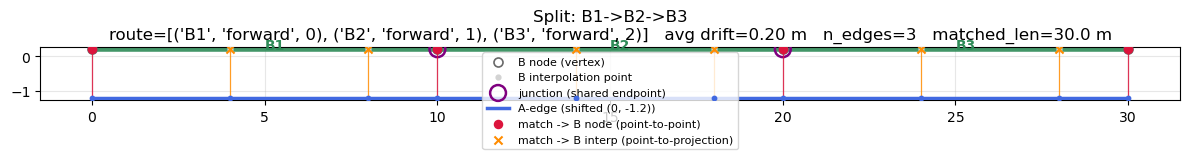

In [3]:
coords_a = [(0.0, 0.0), (30.0, 0.0)]
b_edges = [
    ("B1", LineString([(0, 0.2), (10, 0.2)])),
    ("B2", LineString([(10, 0.2), (20, 0.2)])),
    ("B3", LineString([(20, 0.2), (30, 0.2)])),
]
_ = plot_match(coords_a, b_edges, "Split: B1->B2->B3",
               a_shift=(0, -1.2), snap_tolerance_m=0.5, step_meters=4.0)


## 2. Isolated parallel road rejected (the core win)

`B4` is a single full-length parallel road; edge-to-edge would pick it. Disconnected, so
graph-DTW prefers the connected `B1->B2->B3` corridor.

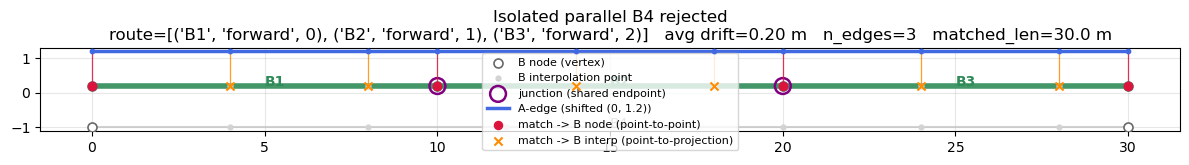

In [4]:
coords_a = [(0.0, 0.0), (30.0, 0.0)]
b_edges = [
    ("B1", LineString([(0, 0.2), (10, 0.2)])),
    ("B2", LineString([(10, 0.2), (20, 0.2)])),
    ("B3", LineString([(20, 0.2), (30, 0.2)])),
    ("B4", LineString([(0, -1.0), (30, -1.0)])),
]
_ = plot_match(coords_a, b_edges, "Isolated parallel B4 rejected",
               a_shift=(0, 1.2), snap_tolerance_m=0.5, step_meters=4.0)


## 3. Cycle in the graph

A loop `B1 -> B2 -> B3` plus `B4` leaving along A. The route goes straight through, not up the loop.

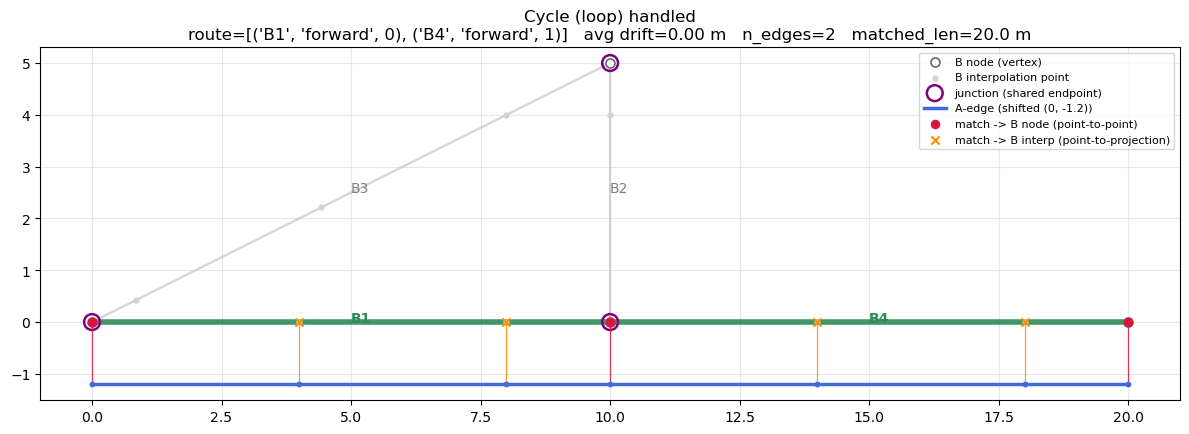

In [5]:
coords_a = [(0.0, 0.0), (10.0, 0.0), (20.0, 0.0)]
b_edges = [
    ("B1", LineString([(0, 0), (10, 0)])),
    ("B2", LineString([(10, 0), (10, 5)])),
    ("B3", LineString([(10, 5), (0, 0)])),
    ("B4", LineString([(10, 0), (20, 0)])),
]
_ = plot_match(coords_a, b_edges, "Cycle (loop) handled",
               a_shift=(0, -1.2), snap_tolerance_m=0.5, step_meters=4.0)


## 4. One-way restriction

`B_wrong` is digitized against A and marked one-way -> graph-DTW falls back to `B_ok`.

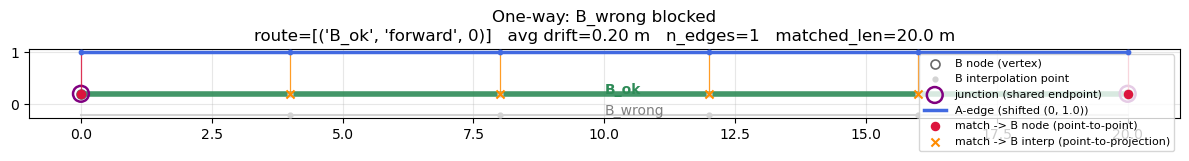

In [6]:
coords_a = [(0.0, 0.0), (20.0, 0.0)]
b_edges = [
    ("B_ok",    LineString([(0, 0.2), (20, 0.2)])),
    ("B_wrong", LineString([(20, -0.2), (0, -0.2)])),
]
_ = plot_match(coords_a, b_edges, "One-way: B_wrong blocked",
               a_shift=(0, 1.0), snap_tolerance_m=0.5, step_meters=4.0, oneway_ids={"B_wrong"})


## 5. A curved corridor

A curved A-edge stitched across several curved, slightly-offset B-edges -- here you can see the
point-to-projection matches clearly where A's nodes land between B's nodes.

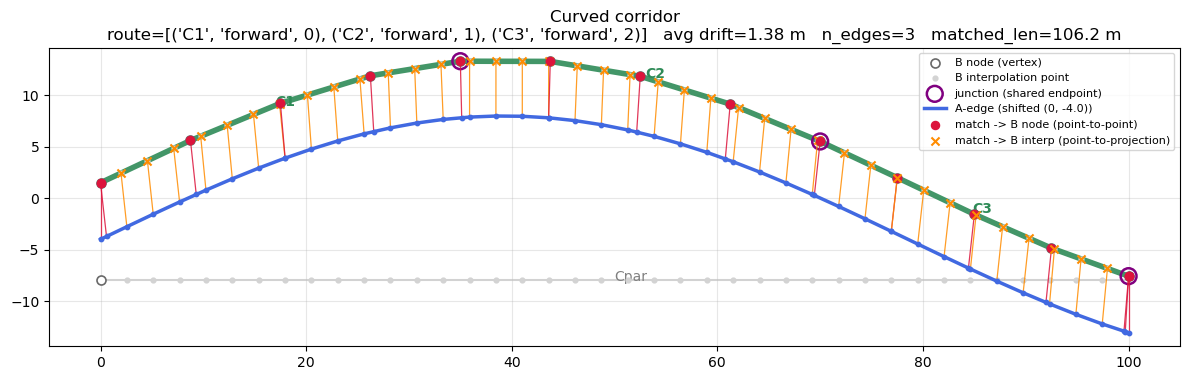

In [7]:
x = np.linspace(0, 100, 40)
y = 12.0 * np.sin(x / 25.0)
coords_a = list(zip(x, y))

def curve(x0, x1, off):
    xs = np.linspace(x0, x1, max(2, int((x1 - x0) / 6)))
    ys = 12.0 * np.sin(xs / 25.0) + off
    return LineString(list(zip(xs, ys)))

b_edges = [
    ("C1", curve(0, 35, 1.5)),
    ("C2", curve(35, 70, 1.5)),
    ("C3", curve(70, 100, 1.5)),
    ("Cpar", LineString([(0, -8), (100, -8)])),
]
_ = plot_match(coords_a, b_edges, "Curved corridor",
               a_shift=(0, -4.0), snap_tolerance_m=1.0, step_meters=5.0)
